In [24]:
import numpy as np
from numpy import array, arange, zeros, ones, concatenate, linspace
import pickle

from scipy.stats import gaussian_kde
import seaborn as sns


import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.family']='serif'
plt.rcParams['axes.unicode_minus']=True
plt.rcParams.update({'font.size': 18, 'text.latex.preamble': r'\usepackage{amsfonts, amsmath}', 'text.usetex': True})

In [2]:
def geo_mean_overflow(iterable):
    return np.exp(np.nanmean(np.log(iterable)))

In [3]:
n_list = arange(4, 11)
k = 2

s_min = 0
s_max = 49
r_min = 0
r_max = 19
p_min = 1
p_max = 150

In [4]:
path = "/home/investigator/Work/qaoa-qfi/Data/"
post = "-prevsol" 
file_name = path + "sat-" + f"n=({n_list[0]},{n_list[-1]})-k={k}-m=2n-p=({p_min},{p_max})-s=({s_min},{s_max})-r=({r_min},{r_max})" + post 

In [5]:
with open(file_name + ".dict", 'rb') as fp:
    data_dict = pickle.load(fp)
data_dict.keys()

/tmp/ipykernel_2693441/1226660697.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_dict = pickle.load(fp)


dict_keys(['m', 'n_list', 's_min', 's_max', 'r_min', 'r_max', 'p_min', 'p_max', 'funs_list', 'errors_list', 'nits_list', 'nfevs_list', 'times_list', 'EQD_list', 'H_diag_list', 'note'])

In [6]:
errors_list = data_dict["errors_list"]
EQD_list = data_dict["EQD_list"]
p_c_list = np.floor(np.max(EQD_list, axis=2)/2)

In [7]:
### count converged ###

discard_nonconv = False
cumulative = True
error_threshold = 1e-8

p_star_list = [] # [m][s]
counts_list = []
bad_indeces_list = []
for n_i in range(len(n_list)):
    counts_n = []
    p_stars_n = []
    bad_indeces_n = []
    for s in range(s_min, s_max + 1):
        drop_flag = False
        counts_s = zeros(p_max - p_min + 1)
        p_star_s = 2**(n_list[n_i]) - 1
        for r in range(r_min, r_max + 1):
            counts_r = zeros(p_max - p_min + 1)
            for p_i in range(p_max - p_min):
                if errors_list[n_i][s][r][p_i] < error_threshold:
                    drop_flag = True
                    if p_i + 1 < p_star_s:
                        p_star_s = p_i + 1# p_i is an index: +1 for counting from zero and +1 for the next p 
                    if cumulative == True:
                        counts_r += concatenate([zeros(p_i + 1), ones(p_max - p_min - p_i)])
                        break
                    else:
                        counts_r[p_i + 1] += 1
            counts_s += counts_r
        if drop_flag == False:
            print(f"No convergence for (thr={error_threshold}, prob={n_list[n_i]}, s={s})")
            if discard_nonconv == True:
                p_star_s = np.nan
            bad_indeces_n.append( s )
        counts_n.append(counts_s)
        p_stars_n.append(p_star_s)
    p_star_list.append(p_stars_n)
    counts_list.append(counts_n)
    bad_indeces_list.append(bad_indeces_n)

No convergence for (thr=1e-08, prob=8, s=7)
No convergence for (thr=1e-08, prob=8, s=9)
No convergence for (thr=1e-08, prob=8, s=23)
No convergence for (thr=1e-08, prob=8, s=38)
No convergence for (thr=1e-08, prob=8, s=43)
No convergence for (thr=1e-08, prob=9, s=4)
No convergence for (thr=1e-08, prob=9, s=8)
No convergence for (thr=1e-08, prob=9, s=32)
No convergence for (thr=1e-08, prob=9, s=37)
No convergence for (thr=1e-08, prob=9, s=42)
No convergence for (thr=1e-08, prob=9, s=43)
No convergence for (thr=1e-08, prob=10, s=4)
No convergence for (thr=1e-08, prob=10, s=13)
No convergence for (thr=1e-08, prob=10, s=15)
No convergence for (thr=1e-08, prob=10, s=23)
No convergence for (thr=1e-08, prob=10, s=28)
No convergence for (thr=1e-08, prob=10, s=38)
No convergence for (thr=1e-08, prob=10, s=42)
No convergence for (thr=1e-08, prob=10, s=44)
No convergence for (thr=1e-08, prob=10, s=47)
No convergence for (thr=1e-08, prob=10, s=48)


In [11]:
### count converged ###

discard_nonconv = False
cumulative = True
error_threshold_2 = 1e-1

p_star_list_2 = [] # [m][s]
counts_list_2 = []
bad_indeces_list_2 = []
for n_i in range(len(n_list)):
    counts_n = []
    p_stars_n = []
    bad_indeces_n = []
    for s in range(s_min, s_max + 1):
        drop_flag = False
        counts_s = zeros(p_max - p_min + 1)
        p_star_s = 2**(n_list[n_i]) - 1
        for r in range(r_min, r_max + 1):
            counts_r = zeros(p_max - p_min + 1)
            for p_i in range(p_max - p_min):
                if errors_list[n_i][s][r][p_i] < error_threshold_2:
                    drop_flag = True
                    if p_i + 1 < p_star_s:
                        p_star_s = p_i + 1# p_i is an index: +1 for counting from zero and +1 for the next p 
                    if cumulative == True:
                        counts_r += concatenate([zeros(p_i + 1), ones(p_max - p_min - p_i)])
                        break
                    else:
                        counts_r[p_i + 1] += 1
            counts_s += counts_r
        if drop_flag == False:
            print(f"No convergence for (thr={error_threshold_2}, prob={n_list[n_i]}, s={s})")
            if discard_nonconv == True:
                p_star_s = np.nan
            bad_indeces_n.append( s )
        counts_n.append(counts_s)
        p_stars_n.append(p_star_s)
    p_star_list_2.append(p_stars_n)
    counts_list_2.append(counts_n)
    bad_indeces_list_2.append(bad_indeces_n)

In [8]:
errors_min_list = np.min(errors_list, axis=2)
errors_min_cum_list = []
for n_i in range(len(n_list)):
    errors_min_cum_n = []
    for s in range(s_min, s_max + 1):
        errors_min_cum_s = [errors_min_list[n_i][s][0]]
        for p in range(1, p_max - p_min + 1):
            if errors_min_list[n_i][s][p] < errors_min_cum_s[-1]:
                errors_min_cum_s.append(errors_min_list[n_i][s][p])
            else:
                errors_min_cum_s.append(errors_min_cum_s[-1])
        errors_min_cum_n.append(errors_min_cum_s)
    errors_min_cum_list.append(errors_min_cum_n)

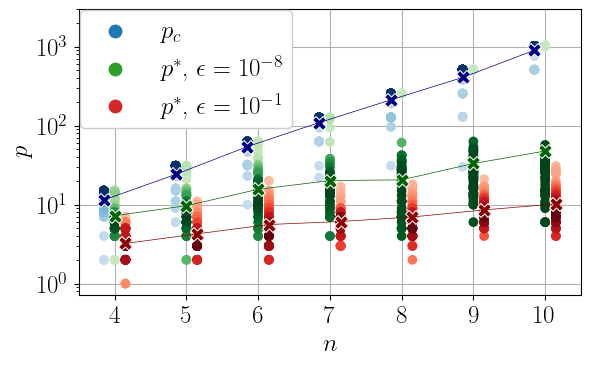

In [67]:
matplotlib.rcParams.update({'font.size': 18})

n_s = (s_max - s_min + 1)
sh = 0.15

cmap_p = plt.get_cmap('Blues')
colors_p = cmap_p(np.linspace(0.25, 1, cmap_p.N))
cmap_p = LinearSegmentedColormap.from_list('Blues', colors_p)

cmap_m = plt.get_cmap("Greens")
colors_m = cmap_m(np.linspace(0.25, 1, cmap_m.N))
cmap_m = LinearSegmentedColormap.from_list("Greens", colors_m)

cmap_r = plt.get_cmap("Reds")
colors_r = cmap_r(np.linspace(0.25, 1, cmap_r.N))
cmap_r = LinearSegmentedColormap.from_list("Reds", colors_r)

plt.figure(figsize=(6.25, 4))
for n_i in range(len(n_list) - 0):

    x_p = array([n_list[n_i] - sh]*len(p_c_list[n_i]))
    y_p = array(p_c_list[n_i])
    c_p = gaussian_kde(p_c_list[n_i])(p_c_list[n_i])
    idx = c_p.argsort()
    x_p, y_p, c_p = x_p[idx], y_p[idx], c_p[idx]
    plot_p = plt.scatter(x_p, y_p, c=c_p, cmap=cmap_p, s=None, alpha=1, zorder=10)

    x_m = array([n_list[n_i]]*len(p_star_list[n_i]))
    y_m = array(p_star_list[n_i])
    c_m = gaussian_kde(p_star_list[n_i])(p_star_list[n_i])
    idx = c_m.argsort()
    x_m, y_m, c_m = x_m[idx], y_m[idx], c_m[idx]
    plot_m = plt.scatter(x_m, y_m, c=c_m, cmap=cmap_m, s=None, alpha=1, zorder=10)

    x_r = array([n_list[n_i] + sh]*len(p_star_list_2[n_i]))
    y_r = array(p_star_list_2[n_i])
    c_r = gaussian_kde(p_star_list_2[n_i])(p_star_list_2[n_i])
    idx = c_r.argsort()
    x_r, y_r, c_r = x_r[idx], y_r[idx], c_r[idx]
    plotrm = plt.scatter(x_r, y_r, c=c_r, cmap=cmap_r, s=None, alpha=1, zorder=10)

plt.scatter([999], [0], color="tab:blue", s=80, alpha=1, zorder=10, label=r"$p_c$")
plt.scatter([999], [0], color="tab:green", s=80, alpha=1, zorder=10, label=r"$p^*$, $\epsilon=10^{-8}$")
plt.scatter([999], [0], color="tab:red", s=80, alpha=1, zorder=10, label=r"$p^*$, $\epsilon=10^{-1}$")
plt.scatter(n_list - sh, [geo_mean_overflow(x) for x in p_c_list], zorder=11, marker="X", ec="white", linewidth=0.75, color="navy", s=100)
plt.scatter(n_list, [geo_mean_overflow(x) for x in p_star_list], zorder=11, marker="X", ec="white", linewidth=0.75, color="darkgreen", s=100)
plt.scatter(n_list + sh, [geo_mean_overflow(x) for x in p_star_list_2], zorder=11, marker="X", ec="white", linewidth=0.75, color="darkred", s=100)

plt.plot(n_list - sh, [geo_mean_overflow(x) for x in p_c_list], zorder=11, linewidth=0.5, color="navy")
plt.plot(n_list, [geo_mean_overflow(x) for x in p_star_list], zorder=11, linewidth=0.5, color="darkgreen")
plt.plot(n_list + sh, [geo_mean_overflow(x) for x in p_star_list_2], zorder=11, linewidth=0.5, color="darkred")

plt.xticks(n_list)
plt.xlabel(r"$n$")
plt.ylabel(r"$p$")
plt.yscale("log")
plt.xlim(n_list[0] - 0.5, n_list[-1] + 0.5)
plt.ylim(ymax=3000)
plt.legend(framealpha=1, bbox_to_anchor=(0.45, 1.04))
plt.grid(zorder=1)
plt.tight_layout()
# plt.savefig("p_c-vs-p_star-three.pdf", transparent=True, bbox_inches='tight')
plt.show()

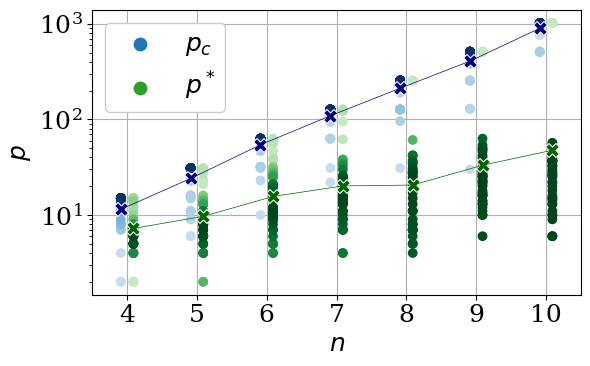

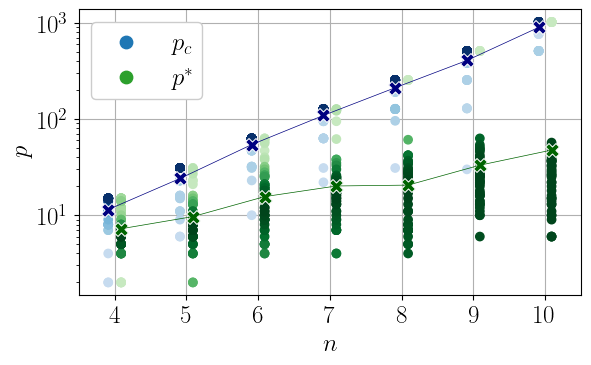